# Word2Vec Pillar Lexicon Learning

**Goal:** Learn pillar-specific vocabularies (Athletic, Technical, Character, Football IQ) from the scouting corpus using Word2Vec, rather than relying solely on manually crafted archetype strings.

**Pipeline:**

| Step | What it does |
|------|-------------|
| 1 | NFL-aware preprocessing (reuse from `nfl_pre_proc`) |
| 2 | Train Word2Vec on the full cleaned corpus |
| 3 | Expand each pillar's seed terms via nearest-neighbor lookup |
| 4 | Inspect & prune the learned vocabularies |
| 5 | Re-score players using embedding-weighted archetype vectors |
| 6 | Compare vs original cosine-similarity scoring |

## 0. Setup

In [34]:
import re
import warnings
import numpy as np
import pandas as pd
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

from gensim.models import Word2Vec

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(resource, quiet=True)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

# ── Controls ──────────────────────────────────────────────────────────────────
YEAR_MIN       = 2014
YEAR_MAX       = 2026
GRADE_MAX      = 8.0

W2V_DIM        = 100   # embedding dimension
W2V_WINDOW     = 6     # context window (wider = more topical, not just syntactic)
W2V_MIN_COUNT  = 3     # ignore tokens appearing fewer than N times
W2V_EPOCHS     = 30    # more epochs = better for small corpora
W2V_SG         = 1     # 1=skip-gram (better for rare words), 0=CBOW

SEED_TOPN      = 20    # nearest neighbors to retrieve per seed term
EXPAND_TOPN    = 15    # top neighbors to keep per pillar after aggregation
SIM_THRESHOLD  = 0.35  # minimum cosine similarity to a seed to be included

PMI_MIN_FREQ   = 5
PMI_TOP_N      = 30

# Seed mode — controls which pillar seed set is used in Section 4
# Options:
#   "4-pillar"  — original 4 archetypes: athletic / technical / character / iq
#   "2-bin"     — binary taxonomy: god_given (ceiling) vs learned (floor)
SEED_MODE = "2-bin"
# SCORE_COLS is set dynamically in the seeds cell after SEED_MODE selection

print('Setup complete.')

Setup complete.


## 1. Load Data

In [35]:
df_raw = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')
df_raw = df_raw[(df_raw['year'] >= YEAR_MIN) & (df_raw['year'] <= YEAR_MAX)].copy()
df_raw = df_raw[df_raw['grade'] <= GRADE_MAX].copy()

def combine_text(row):
    parts = [str(row.get(c, '') or '') for c in ['overview', 'strengths', 'weaknesses']]
    return ' '.join(p for p in parts if p.strip())

df_raw['combined_text'] = df_raw.apply(combine_text, axis=1)
df_raw = df_raw[df_raw['combined_text'].str.strip() != ''].reset_index(drop=True)

print(f'Players loaded: {len(df_raw)}')
print(f'Pos_Group distribution:\n{df_raw["Pos_Group"].value_counts().to_string()}')

Players loaded: 5539
Pos_Group distribution:
Pos_Group
DB         1057
OL          930
WR          776
EDGE        668
RB          511
DT          453
LB          435
TE          323
QB          239
SPECIAL     147


## 2. NFL-Aware Preprocessing

Same curated phrase map and stop word logic as `nfl_pre_proc.ipynb` — kept here so the notebook is self-contained.

In [36]:
_CURATED_RAW = {
    # Trigrams — apply before bigrams
    'change of direction':   'change_of_direction',
    'low pad level':         'low_pad_level',
    'run after catch':       'run_after_catch',
    'yards after contact':   'yards_after_contact',
    'yards after catch':     'yards_after_catch',
    'off the line':          'off_the_line',
    'off the ball':          'off_the_ball',
    'point of attack':       'point_of_attack',
    'get off the':           'get_off',
    'high football iq':      'high_football_iq',
    'elite football iq':     'elite_football_iq',
    'pre snap read':         'pre_snap_read',
    'post snap reaction':    'post_snap_reaction',
    # Bigrams
    'pass rush':             'pass_rush',
    'pass rusher':           'pass_rusher',
    'pass protection':       'pass_protection',
    'pass coverage':         'pass_coverage',
    'pad level':             'pad_level',
    'press coverage':        'press_coverage',
    'man coverage':          'man_coverage',
    'zone coverage':         'zone_coverage',
    'ball skills':           'ball_skills',
    'ball hawk':             'ball_hawk',
    'ball carrier':          'ball_carrier',
    'body control':          'body_control',
    'contact balance':       'contact_balance',
    'closing speed':         'closing_speed',
    'lateral quickness':     'lateral_quickness',
    'quick twitch':          'quick_twitch',
    'high motor':            'high_motor',
    'first step':            'first_step',
    'get off':               'get_off',
    'hand fighting':         'hand_fighting',
    'hand strength':         'hand_strength',
    'hand placement':        'hand_placement',
    'block shedding':        'block_shedding',
    'anchor strength':       'anchor_strength',
    'route running':         'route_running',
    'run blocking':          'run_blocking',
    'open field':            'open_field',
    'red zone':              'red_zone',
    'second level':          'second_level',
    'hip flexibility':       'hip_flexibility',
    'hip flip':              'hip_flip',
    'open hips':             'open_hips',
    'soft hands':            'soft_hands',
    'heavy hands':           'heavy_hands',
    'strong hands':          'strong_hands',
    'short area':            'short_area',
    'three down':            'three_down',
    'top end':               'top_end',
    'two gap':               'two_gap',
    'one gap':               'one_gap',
    'snap count':            'snap_count',
    'straight line':         'straight_line',
    'play speed':            'play_speed',
    'play recognition':      'play_recognition',
    'pre snap':              'pre_snap',
    'post snap':             'post_snap',
    'run read':              'run_read',
    'pass recognition':      'pass_recognition',
    'eye discipline':        'eye_discipline',
    'coverage recognition':  'coverage_recognition',
    'zone recognition':      'zone_recognition',
    'gap integrity':         'gap_integrity',
    'assignment sound':      'assignment_sound',
    'compete level':         'compete_level',
    'effort level':          'effort_level',
    'pursuit angle':         'pursuit_angle',
    'pass set':              'pass_set',
    'stack shed':            'stack_shed',
    'inside leverage':       'inside_leverage',
    'outside leverage':      'outside_leverage',
    'shed block':            'shed_block',
    'rush ability':          'rush_ability',
    'vertical jump':         'vertical_jump',
    'arm length':            'arm_length',
    'burst speed':           'burst_speed',
    # ── Added: fix stop-word collision on "game-ready"; common craft phrases ──
    # "game-ready" → hyphen → "game ready" → 'game' is in CUSTOM_STOPS
    # Stitching runs BEFORE stop filter, so this preserves the token
    'game ready':            'game_ready',
    'hard worker':           'hard_worker',
    'work ethic':            'work_ethic',
}

CURATED_PHRASE_MAP = dict(
    sorted(_CURATED_RAW.items(), key=lambda x: len(x[0]), reverse=True)
)
print(f'Curated phrases: {len(CURATED_PHRASE_MAP)}')

Curated phrases: 81


In [37]:
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'good', 'great', 'up', 'down',
    'off', 'out', 'over', 'through', 'above', 'below',
}

CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'ability', 'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'work', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'level', 'type', 'project', 'potential', 'upside', 'ceiling',
    # Additional generic filler
    'tape', 'film', 'tool', 'tools', 'solid', 'impressive', 'way',
    'thing', 'things', 'scout', 'scouting', 'frame',
}

_base = set(stopwords.words('english'))
NFL_STOPWORDS = (_base - KEEP_WORDS) | CUSTOM_STOPS

print(f'Final stop list: {len(NFL_STOPWORDS)}')

Final stop list: 237


In [38]:
lemmatizer = WordNetLemmatizer()

PHRASE_BLOCKLIST = [
    'undrafted free agent', 'practice squad', 'free agent', 'early starter',
    'pro bowl', 'late round', 'undrafted free', 'make roster', 'rostered',
]

def nfl_preprocess(text: str, phrase_map: dict = CURATED_PHRASE_MAP,
                   extra_phrases: dict = None) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    for phrase in sorted(PHRASE_BLOCKLIST, key=len, reverse=True):
        text = text.replace(phrase, ' ')
    text = re.sub(r'[-\u2013\u2014]', ' ', text)
    for phrase, token in phrase_map.items():
        text = text.replace(phrase, token)
    if extra_phrases:
        for phrase, token in extra_phrases.items():
            text = text.replace(phrase, token)
    text = re.sub(r'[^a-z_\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if '_' in t or t not in NFL_STOPWORDS]
    tokens = [t if '_' in t else lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 1]
    return ' '.join(tokens)


# Pass 1: curated phrases only (for PMI discovery)
df_raw['text_v1'] = df_raw['combined_text'].apply(nfl_preprocess)

# PMI bigram discovery on v1-cleaned text
_token_lists_pmi = [
    [t for t in text.split() if '_' not in t]
    for text in df_raw['text_v1']
]
finder = BigramCollocationFinder.from_documents(_token_lists_pmi)
finder.apply_freq_filter(PMI_MIN_FREQ)
scored = finder.score_ngrams(BigramAssocMeasures.pmi)
_already = set(CURATED_PHRASE_MAP.keys())
auto_candidates = [
    (w1, w2, round(score, 3))
    for (w1, w2), score in scored
    if  w1 not in NFL_STOPWORDS and w2 not in NFL_STOPWORDS
    and w1.isalpha() and w2.isalpha()
    and len(w1) > 2 and len(w2) > 2
    and f'{w1} {w2}' not in _already
][:PMI_TOP_N]

AUTO_PHRASE_MAP = dict(sorted(
    {f'{w1} {w2}': f'{w1}_{w2}' for w1, w2, _ in auto_candidates}.items(),
    key=lambda x: len(x[0]), reverse=True
))

# Final pass: curated + PMI phrases — combined text (used for W2V training)
df_raw['text_clean'] = df_raw['combined_text'].apply(
    lambda t: nfl_preprocess(t, extra_phrases=AUTO_PHRASE_MAP)
)

# Section-specific passes — same pipeline, each section separately
# Used for section-aware scoring (strengths vs weaknesses analysis)
for raw_col, clean_col in [('strengths',  'strengths_clean'),
                            ('weaknesses', 'weaknesses_clean')]:
    df_raw[clean_col] = df_raw[raw_col].fillna('').apply(
        lambda t: nfl_preprocess(t, extra_phrases=AUTO_PHRASE_MAP)
    )

df_raw = df_raw[df_raw['text_clean'] != ''].reset_index(drop=True)

vocab = set(t for text in df_raw['text_clean'] for t in text.split())
print(f'Documents: {len(df_raw):,}')
print(f'Vocabulary: {len(vocab):,} unique tokens  ({sum(1 for t in vocab if "_" in t)} stitched)')
print(f'Strengths coverage : {(df_raw["strengths_clean"] != "").sum():,}')
print(f'Weaknesses coverage: {(df_raw["weaknesses_clean"] != "").sum():,}')

Documents: 5,539
Vocabulary: 12,739 unique tokens  (154 stitched)
Strengths coverage : 5,376
Weaknesses coverage: 5,377


## 3. Train Word2Vec

We use **skip-gram** (`sg=1`) which performs better than CBOW for rare/specialized vocabulary — exactly what scouting language is. Stitched tokens (`pass_rush`, `high_motor`) are treated as single units, so the model learns their full semantic context.

In [39]:
token_lists = [text.split() for text in df_raw['text_clean']]

w2v = Word2Vec(
    sentences=token_lists,
    vector_size=W2V_DIM,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    sg=W2V_SG,
    epochs=W2V_EPOCHS,
    seed=42,
    workers=4,
)

print(f'Vocabulary size (Word2Vec): {len(w2v.wv):,}')
print(f'Embedding dimension: {w2v.wv.vector_size}')

# Quick sanity checks
sanity_pairs = [
    ('pass_rush', 'get_off'),
    ('high_motor', 'relentless'),
    ('route_running', 'route'),
    ('explosive', 'burst'),
    ('football', 'instinct'),
]
print('\nSanity: cosine similarities between related terms')
for a, b in sanity_pairs:
    if a in w2v.wv and b in w2v.wv:
        sim = w2v.wv.similarity(a, b)
        print(f'  {a:30s} ↔ {b:25s}  {sim:.3f}')
    else:
        missing = [x for x in [a, b] if x not in w2v.wv]
        print(f'  {a} ↔ {b}  — missing: {missing}')

Vocabulary size (Word2Vec): 6,876
Embedding dimension: 100

Sanity: cosine similarities between related terms
  pass_rush                      ↔ get_off                    0.543
  high_motor                     ↔ relentless                 0.390
  route_running                  ↔ route                      0.520
  explosive                      ↔ burst                      0.355
  football                       ↔ instinct                   0.299


## 4. Expand Pillar Seed Terms via Nearest Neighbors

For each pillar we define a small, high-confidence **seed set** of 6–10 terms. We then find the top-N nearest neighbors to *each seed* and aggregate them. Terms appearing near multiple seeds rank higher (more robust to any single seed being noisy).

**Why this is better than manual archetypes:**
- Discovers synonyms and co-occurring patterns the curated list missed
- Grounded in the actual language distribution of your corpus
- The similarity threshold prunes noise automatically

In [40]:
# ── 4-Pillar seeds (original) ─────────────────────────────────────────────────
PILLAR_SEEDS_4PILLAR = {
    'score_athletic': [
        'explosive', 'burst', 'speed', 'quick_twitch', 'acceleration',
        'agile', 'change_of_direction', 'first_step', 'get_off', 'twitch',
    ],
    'score_technical': [
        'technique', 'footwork', 'leverage', 'pad_level', 'hand_fighting',
        'anchor_strength', 'route_running', 'block_shedding', 'hand_placement',
        'pass_protection',
    ],
    'score_character': [
        'high_motor', 'motor', 'effort', 'relentless', 'competitive',
        'toughness', 'hustle', 'compete_level', 'grit', 'intensity',
    ],
    'score_iq': [
        'football', 'instinct', 'anticipation', 'awareness', 'recognition',
        'diagnosis', 'pre_snap', 'play_recognition', 'intelligence', 'vision',
    ],
}

# ── 2-Bin seeds (god_given ceiling vs learned floor) ──────────────────────────
# Anchor seeds should be high-frequency scouting terms that are reliably
# in the W2V vocabulary. W2V expansion discovers related vocabulary
# (stamina, diagnose, shed, craft, etc.) without manually listing them.
PILLAR_SEEDS_2BIN = {
    'score_god_given': [
        # Raw physical tools — uncoachable ceiling anchors
        'explosive', 'burst', 'speed', 'quick_twitch', 'get_off',
        'twitch', 'twitchy', 'acceleration', 'first_step',
        'change_of_direction', 'agility', 'frame', 'size',
    ],
    'score_learned': [
        # Craft, discipline, neck-up traits — coachable floor anchors
        'technique', 'footwork', 'leverage', 'high_motor', 'motor',
        'effort', 'relentless', 'toughness', 'intelligence',
        'awareness', 'recognition', 'instinct', 'discipline',
        'pad_level', 'fundamental',
    ],
}

# ── Seed selection based on SEED_MODE ─────────────────────────────────────────
if SEED_MODE == "2-bin":
    PILLAR_SEEDS = PILLAR_SEEDS_2BIN
    SCORE_COLS   = ['score_god_given', 'score_learned']
    print(f'Seed mode: 2-BIN  (God-Given Ceiling vs Learned & Controlled Floor)')
else:
    PILLAR_SEEDS = PILLAR_SEEDS_4PILLAR
    SCORE_COLS   = ['score_athletic', 'score_technical', 'score_character', 'score_iq']
    print(f'Seed mode: 4-PILLAR  (Athletic / Technical / Character / IQ)')

# Vocab check — seeds must be in the W2V vocabulary (min_count controls this)
print(f'\nSeeds per pillar:')
for pillar, seeds in PILLAR_SEEDS.items():
    in_vocab = [s for s in seeds if s in w2v.wv]
    missing  = [s for s in seeds if s not in w2v.wv]
    print(f'  {pillar}: {len(in_vocab)}/{len(seeds)} in vocab'
          + (f'  MISSING: {missing}' if missing else ''))

all_seeds = [s for seeds in PILLAR_SEEDS.values() for s in seeds]
in_vocab  = [s for s in all_seeds if s in w2v.wv]
print(f'\nTotal seeds in W2V vocab: {len(in_vocab)}/{len(all_seeds)}')

Seed mode: 2-BIN  (God-Given Ceiling vs Learned & Controlled Floor)

Seeds per pillar:
  score_god_given: 13/13 in vocab
  score_learned: 15/15 in vocab

Total seeds in W2V vocab: 28/28


In [41]:
def expand_pillar(seeds: list, model: Word2Vec, topn: int = SEED_TOPN,
                  threshold: float = SIM_THRESHOLD) -> pd.DataFrame:
    """
    For each seed in vocab, retrieve top-N nearest neighbors.
    Aggregate by counting how many seeds each candidate appears near
    and averaging the similarity scores.
    Returns a DataFrame sorted by (seed_count DESC, avg_sim DESC).
    """
    candidate_scores: dict[str, list[float]] = {}

    for seed in seeds:
        if seed not in model.wv:
            continue
        neighbors = model.wv.most_similar(seed, topn=topn)
        for word, sim in neighbors:
            if sim >= threshold and word not in seeds:
                candidate_scores.setdefault(word, []).append(sim)

    if not candidate_scores:
        return pd.DataFrame(columns=['term', 'seed_count', 'avg_sim', 'max_sim'])

    rows = [
        {
            'term':       word,
            'seed_count': len(sims),
            'avg_sim':    round(float(np.mean(sims)), 3),
            'max_sim':    round(float(np.max(sims)), 3),
        }
        for word, sims in candidate_scores.items()
    ]
    df_out = pd.DataFrame(rows).sort_values(
        ['seed_count', 'avg_sim'], ascending=False
    ).reset_index(drop=True)
    return df_out


LEARNED_LEXICONS: dict[str, pd.DataFrame] = {}
for pillar, seeds in PILLAR_SEEDS.items():
    LEARNED_LEXICONS[pillar] = expand_pillar(seeds, w2v)

print('Lexicon expansion complete.')
for pillar, lex in LEARNED_LEXICONS.items():
    print(f'  {pillar}: {len(lex)} candidates found')

Lexicon expansion complete.
  score_god_given: 182 candidates found
  score_learned: 231 candidates found


## 5. Inspect Learned Lexicons

Review the top learned terms per pillar. High `seed_count` = term appears near multiple seeds = high confidence it belongs to that pillar. Terms with `seed_count=1` are noisier.

In [42]:
# Build labels dynamically so this works for both seed modes
_ALL_LABELS = {
    'score_athletic':  'Athletic Profile',
    'score_technical': 'Technical Skills',
    'score_character': 'Competitive Character',
    'score_iq':        'Football IQ',
    'score_god_given': 'God-Given Ceiling',
    'score_learned':   'Learned Floor',
}
PILLAR_LABELS = {
    col: _ALL_LABELS.get(col, col.replace('score_', '').replace('_', ' ').title())
    for col in SCORE_COLS
}

for pillar in SCORE_COLS:
    lex = LEARNED_LEXICONS[pillar]
    print(f'\n{"═" * 60}')
    print(f'  {PILLAR_LABELS[pillar].upper()}')
    print(f'  Seeds: {PILLAR_SEEDS[pillar]}')
    print(f'  Top {EXPAND_TOPN} learned terms:')
    print(f'  {"─" * 58}')
    print(lex.head(EXPAND_TOPN).to_string(index=False))


════════════════════════════════════════════════════════════
  GOD-GIVEN CEILING
  Seeds: ['explosive', 'burst', 'speed', 'quick_twitch', 'get_off', 'twitch', 'twitchy', 'acceleration', 'first_step', 'change_of_direction', 'agility', 'frame', 'size']
  Top 15 learned terms:
  ──────────────────────────────────────────────────────────
             term  seed_count  avg_sim  max_sim
        quickness           4    0.584    0.627
       short_area           4    0.578    0.646
          redmond           4    0.572    0.623
          top_end           3    0.599    0.701
            juice           3    0.579    0.608
       play_speed           3    0.558    0.629
         fluidity           3    0.530    0.550
        looseness           3    0.519    0.568
        confirmed           3    0.506    0.530
           pearce           3    0.506    0.545
          lateral           2    0.658    0.668
         reactive           2    0.646    0.658
          closing           2    0.593 

In [43]:
# Cross-pillar overlap: terms that appear in more than one pillar's top candidates
# High overlap = ambiguous terms that may not be useful for discrimination
top_per_pillar = {
    pillar: set(LEARNED_LEXICONS[pillar].head(EXPAND_TOPN)['term'].tolist())
    for pillar in SCORE_COLS
}

all_terms = [t for terms in top_per_pillar.values() for t in terms]
term_counts = Counter(all_terms)
ambiguous = {t: c for t, c in term_counts.items() if c > 1}

print(f'Terms appearing in multiple pillar top-{EXPAND_TOPN} lists (ambiguous):')
if ambiguous:
    for term, count in sorted(ambiguous.items(), key=lambda x: -x[1]):
        pillars_found = [p for p, s in top_per_pillar.items() if term in s]
        print(f'  {term:30s}  count={count}  pillars={pillars_found}')
else:
    print('  None — pillars are well-separated.')

Terms appearing in multiple pillar top-15 lists (ambiguous):
  None — pillars are well-separated.


## 6. Nearest Neighbors Deep Dive

Spot-check individual key terms to understand what the model learned.

In [44]:
TERMS_TO_PROBE = [
    'pass_rush', 'high_motor', 'football', 'technique',
    'explosive', 'instinct', 'route_running', 'toughness',
    'pre_snap', 'anchor_strength',
]

for term in TERMS_TO_PROBE:
    if term not in w2v.wv:
        print(f'{term}: NOT IN VOCAB')
        continue
    neighbors = w2v.wv.most_similar(term, topn=10)
    neighbor_str = '  |  '.join(f'{w} ({s:.2f})' for w, s in neighbors)
    print(f'\n{term}')
    print(f'  → {neighbor_str}')


pass_rush
  → pass_rusher (0.77)  |  rush (0.76)  |  arsenal (0.68)  |  counter (0.67)  |  rusher (0.61)  |  swim (0.59)  |  vanilla (0.57)  |  get_off (0.54)  |  plan (0.54)  |  handwork (0.53)

high_motor
  → twin (0.59)  |  mcdonald (0.57)  |  ridgeway (0.54)  |  accolade (0.53)  |  overhyped (0.52)  |  unsung (0.50)  |  broadly (0.50)  |  rochell (0.49)  |  lacy (0.49)  |  moss (0.49)

football
  → intelligence (0.60)  |  iq (0.56)  |  ball (0.54)  |  lineage (0.50)  |  vocally (0.49)  |  vein (0.49)  |  tad (0.48)  |  intimidator (0.48)  |  passion (0.48)  |  intangible (0.47)

technique
  → coached (0.53)  |  usage (0.53)  |  fundamental (0.51)  |  messy (0.51)  |  improve (0.51)  |  grappling (0.50)  |  hand_placement (0.49)  |  stoutness (0.49)  |  demby (0.49)  |  seasoning (0.49)

explosive
  → explosiveness (0.62)  |  redmond (0.60)  |  quick_twitch (0.57)  |  twitched (0.56)  |  explosion (0.54)  |  morris (0.54)  |  headline (0.53)  |  elite (0.52)  |  fast (0.52)  |  con

## 7. Scoring — Three Lenses on Each Player

This section produces three complementary views of each player's profile.

---

### Lens 1 — Combined Similarity Score (0–100)

The **W2V combined score** is a cosine similarity between a player's document embedding (mean of all token vectors across strengths + overview + weaknesses text) and the pillar centroid (mean of seed + learned term vectors, seeds double-weighted).

- **What it captures:** How much of the scout's overall vocabulary about this player overlaps semantically with the archetype, even for words not in the seed list. A player described with near-synonyms of athletic language (e.g. *"rare mover"*, *"clocked 4.3"*) scores high on god-given even without exact seed-word matches.
- **What it doesn't capture:** Whether the archetype vocabulary appeared in *praise* or *criticism*. A player whose weaknesses section is full of athletic language (e.g. "not explosive enough") scores as highly athletic as one who's praised for it.

---

### Lens 2 — Quality Score (Strengths − Weaknesses similarity)

For each pillar, separate embeddings are computed from the strengths text and the weaknesses text. The **quality score** is:

```
quality = sim(strengths_embedding, centroid) − sim(weaknesses_embedding, centroid)
```

- **Positive** → the player's god-given/learned traits are discussed as *strengths*. The archetype language appears in praise.
- **Near zero** → balanced — trait mentioned equally in both, or barely mentioned.
- **Negative** → the archetype language appears more in *criticism* — scouts see this as a deficiency.

This is the signal most likely to add predictive lift beyond a numeric grade: a prospect graded 6.0 with a high god-given quality score (praised for ceiling) is a different bet than one graded 6.0 with a negative quality score (critiqued for lack of athleticism).

---

### Lens 3 — Section % Composition

Within each section, row-normalise the bin similarities so they sum to 100%:

```
god_given_str_pct = sim_strengths_god_given / (sim_strengths_god_given + sim_strengths_learned) × 100
```

- **`god_given_str_pct`** — what share of the *strength praise* is oriented toward raw physical traits
- **`learned_str_pct`** — what share of the *strength praise* is oriented toward craft/discipline
- Same pair for weaknesses (`_wk_pct`)

**Example interpretation:** A player with `god_given_str_pct = 75` and `learned_wk_pct = 80` is a classic boom-or-bust profile — scouts rave about the ceiling but critique the floor. A player with `learned_str_pct = 65` and `god_given_wk_pct = 70` is a polished technician flagged for lack of elite tools.

In [45]:
def doc_embedding(text: str, model: Word2Vec) -> np.ndarray | None:
    """Mean of token embeddings for tokens in model vocab."""
    tokens = [t for t in text.split() if t in model.wv]
    if not tokens:
        return None
    return np.mean(model.wv[tokens], axis=0)

_zero = np.zeros(W2V_DIM)

# Combined doc vectors (used for Lens 1 combined score)
doc_vecs = np.array([
    v if (v := doc_embedding(text, w2v)) is not None else _zero
    for text in df_raw['text_clean']
])

# Section-specific doc vectors (used for Lens 2 quality score and Lens 3 % composition)
str_vecs = np.array([
    v if (v := doc_embedding(text, w2v)) is not None else _zero
    for text in df_raw['strengths_clean']
])
wk_vecs = np.array([
    v if (v := doc_embedding(text, w2v)) is not None else _zero
    for text in df_raw['weaknesses_clean']
])

print(f'Combined doc vectors  : {doc_vecs.shape}')
print(f'Strengths doc vectors : {str_vecs.shape}')
print(f'Weaknesses doc vectors: {wk_vecs.shape}')
for name, vecs in [('combined', doc_vecs), ('strengths', str_vecs), ('weaknesses', wk_vecs)]:
    zero_rows = (vecs == 0).all(axis=1).sum()
    print(f'  {name:12s} — zero vectors (no vocab overlap): {zero_rows}')

Combined doc vectors  : (5539, 100)
Strengths doc vectors : (5539, 100)
Weaknesses doc vectors: (5539, 100)
  combined     — zero vectors (no vocab overlap): 0
  strengths    — zero vectors (no vocab overlap): 163
  weaknesses   — zero vectors (no vocab overlap): 162


In [46]:
def pillar_centroid(seeds: list, learned_df: pd.DataFrame,
                    model: Word2Vec, top_learned: int = EXPAND_TOPN) -> np.ndarray:
    """
    Build a pillar centroid by averaging the embeddings of:
    - all seed terms in vocab
    - top `top_learned` learned neighbors
    Seeds are double-weighted (they are the anchor; learned terms expand).
    """
    seed_vecs   = [model.wv[s] for s in seeds if s in model.wv]
    learned_terms = learned_df.head(top_learned)['term'].tolist()
    learned_vecs = [model.wv[t] for t in learned_terms if t in model.wv]

    # Double-weight seeds
    all_vecs = seed_vecs * 2 + learned_vecs

    if not all_vecs:
        return np.zeros(model.vector_size)
    return np.mean(all_vecs, axis=0)


pillar_centroids = {
    pillar: pillar_centroid(PILLAR_SEEDS[pillar], LEARNED_LEXICONS[pillar], w2v)
    for pillar in SCORE_COLS
}

centroid_matrix = np.stack([pillar_centroids[p] for p in SCORE_COLS])   # (4, dim)

print('Pillar centroids built.')
for pillar, vec in pillar_centroids.items():
    print(f'  {pillar:25s}  norm={np.linalg.norm(vec):.3f}')

Pillar centroids built.
  score_god_given            norm=1.713
  score_learned              norm=1.628


In [47]:
# ── Lens 1: Combined similarity score (0-100) ──────────────────────────────────
sim_w2v = cosine_similarity(doc_vecs, centroid_matrix)   # (n_players, n_pillars)

scores_w2v_raw = pd.DataFrame(sim_w2v, columns=SCORE_COLS)

scaler = MinMaxScaler(feature_range=(0, 100))
scores_w2v = pd.DataFrame(
    scaler.fit_transform(scores_w2v_raw),
    columns=SCORE_COLS
).round(1)

result_w2v = pd.concat(
    [df_raw[['player_name', 'position', 'Pos_Group', 'grade',
             'year', 'made_it_contract']].reset_index(drop=True),
     scores_w2v],
    axis=1
)

# ── Lens 2: Quality score (strengths − weaknesses similarity) ──────────────────
sim_str = cosine_similarity(str_vecs, centroid_matrix)   # (n_players, n_pillars)
sim_wk  = cosine_similarity(wk_vecs,  centroid_matrix)   # (n_players, n_pillars)

for i, col in enumerate(SCORE_COLS):
    short = col.replace('score_', '')
    result_w2v[f'{short}_quality'] = (sim_str[:, i] - sim_wk[:, i]).round(4)

# ── Lens 3: Section % composition ─────────────────────────────────────────────
# Row-normalise within each section so bins sum to 100% per player
str_df = pd.DataFrame(sim_str, columns=SCORE_COLS)
wk_df  = pd.DataFrame(sim_wk,  columns=SCORE_COLS)

str_total = str_df.sum(axis=1).replace(0, np.nan)
wk_total  = wk_df.sum(axis=1).replace(0, np.nan)

for col in SCORE_COLS:
    short = col.replace('score_', '')
    result_w2v[f'{short}_str_pct'] = (str_df[col] / str_total * 100).round(1)
    result_w2v[f'{short}_wk_pct']  = (wk_df[col]  / wk_total  * 100).round(1)

print(f'Scoring complete: {len(result_w2v):,} players × {len(result_w2v.columns)} columns')
print('\nSample output (first 5 rows, all new columns):')
display_cols = (['player_name', 'position', 'grade']
                + SCORE_COLS
                + [c for c in result_w2v.columns if '_quality' in c or '_pct' in c])
print(result_w2v[display_cols].head(5).to_string(index=False))

Scoring complete: 5,539 players × 14 columns

Sample output (first 5 rows, all new columns):
     player_name position  grade  score_god_given  score_learned  god_given_quality  learned_quality  god_given_str_pct  god_given_wk_pct  learned_str_pct  learned_wk_pct
Jadeveon Clowney       DE    7.5        68.500000      84.599998             0.1253           0.0309               49.3              45.7             50.7            54.3
   Sammy Watkins       WR    7.1        66.099998      67.500000             0.2184          -0.0223               52.7              42.7             47.3            57.3
    Anthony Barr      OLB    7.0        82.199997      93.300003             0.1324          -0.0905               53.3              45.8             46.7            54.2
     Khalil Mack      OLB    7.0        73.199997      85.699997             0.2346           0.1460               49.4              45.1             50.6            54.9
   Jake Matthews       OT    7.0        59.799999   

## 7b. Section-Level Profile Analysis

Using the three lenses computed above, we can now describe each player's profile more richly:

| Column pattern | What it means |
|---|---|
| `score_god_given` / `score_learned` | Overall semantic similarity (Lens 1) — 0–100 scaled across all players |
| `god_given_quality` / `learned_quality` | Strengths sim − Weaknesses sim (Lens 2) — positive = praised, negative = critiqued |
| `god_given_str_pct` / `learned_str_pct` | % of strength praise devoted to each bin (Lens 3, sums to 100%) |
| `god_given_wk_pct` / `learned_wk_pct` | % of weakness critique devoted to each bin (Lens 3, sums to 100%) |

The tables below show position-level medians — useful for understanding how scouts *allocate* their language by position archetype.

In [48]:
shorts = [col.replace('score_', '') for col in SCORE_COLS]

quality_cols  = [f'{s}_quality'  for s in shorts]
str_pct_cols  = [f'{s}_str_pct'  for s in shorts]
wk_pct_cols   = [f'{s}_wk_pct'   for s in shorts]

# ── Position-level medians ─────────────────────────────────────────────────────
pos_all = result_w2v.groupby('Pos_Group')[
    SCORE_COLS + quality_cols + str_pct_cols + wk_pct_cols
].median().round(2).sort_values(SCORE_COLS[0], ascending=False)

print('LENS 1 — Median combined W2V score by position (0-100)')
print(pos_all[SCORE_COLS].rename(columns={c: c.replace('score_','') for c in SCORE_COLS}).to_string())

print('\nLENS 2 — Median quality score by position  (strengths − weaknesses sim, higher = more praised)')
rename_q = {c: c.replace('_quality', '') for c in quality_cols}
print(pos_all[quality_cols].rename(columns=rename_q).to_string())

print('\nLENS 3a — Median % of STRENGTH praise per bin by position')
print('(what share of strength language is about each archetype)')
rename_s = {c: c.replace('_str_pct', '%_str') for c in str_pct_cols}
print(pos_all[str_pct_cols].rename(columns=rename_s).to_string())

print('\nLENS 3b — Median % of WEAKNESS critique per bin by position')
print('(what share of weakness language is about each archetype)')
rename_w = {c: c.replace('_wk_pct', '%_wk') for c in wk_pct_cols}
print(pos_all[wk_pct_cols].rename(columns=rename_w).to_string())

# ── Gap: how does the % composition shift from strengths to weaknesses? ────────
print('\nGAP (str_pct − wk_pct) per bin by position')
print('Positive = scouts praise this dimension more than they critique it')
gap_df = (pos_all[str_pct_cols].values - pos_all[wk_pct_cols].values)
gap_df = pd.DataFrame(gap_df, index=pos_all.index,
                      columns=[s.replace('_str_pct', '_gap') for s in str_pct_cols])
print(gap_df.round(1).to_string())

LENS 1 — Median combined W2V score by position (0-100)
           god_given    learned
Pos_Group                      
EDGE       80.599998  83.949997
LB         77.900002  86.900002
DB         77.199997  76.699997
DT         76.300003  84.599998
WR         74.400002  63.799999
RB         73.300003  71.400002
TE         71.800003  73.500000
OL         69.699997  81.150002
QB         53.200001  65.900002
SPECIAL    35.099998  44.500000

LENS 2 — Median quality score by position  (strengths − weaknesses sim, higher = more praised)
           god_given  learned
Pos_Group                    
EDGE            0.01     0.00
LB             -0.00     0.02
DB              0.01     0.01
DT              0.02     0.00
WR              0.00     0.01
RB              0.00     0.01
TE              0.01     0.00
OL              0.00     0.01
QB              0.01     0.01
SPECIAL         0.00     0.01

LENS 3a — Median % of STRENGTH praise per bin by position
(what share of strength language is about each

## 8. Compare W2V vs Original TF-IDF Archetype Scoring

Run the original cosine/TF-IDF scoring on the same data, then compare correlations and rank differences.

In [49]:
# ── TF-IDF archetype scoring — matched to SEED_MODE for a fair W2V comparison ─
ARCHETYPES_4PILLAR = {
    'score_athletic': (
        'elite athletic speed explosive burst acceleration lateral quickness '
        'body_control change_of_direction closing_speed explosive_burst '
        'twitch twitchy agile agility flexible flexibility fluid fluidity '
        'vertical jump leap raw physical powerful strength powerful frame '
        'long athletic get_off first_step separation quick_twitch top_end'
    ),
    'score_technical': (
        'technique mechanics footwork hand_fighting hand_strength anchor_strength '
        'pad_level low_pad_level leverage pass_protection run_blocking '
        'route_running block_shedding press_coverage zone_coverage man_coverage '
        'precise precision timing consistent fundamental sound execution '
        'hip_flexibility balance short_area lateral_quickness polish refined '
        'crisp sharp release contested'
    ),
    'score_character': (
        'high_motor motor effort compete relentless hustle competitive '
        'toughness tough grit passion energy aggressive pursuit intensity '
        'leadership character discipline accountable driven focused '
        'diligent committed hard worker never quit battles emotional '
        'physical bully mentality edge'
    ),
    'score_iq': (
        'football iq intelligence smart instinct awareness anticipation '
        'recognition diagnosis read scheme assignment mental processing '
        'pre snap post snap understanding vision cerebral mature prepared '
        'coachable quick processor off_the_ball point_of_attack '
        'chess high football intelligence'
    ),
}

ARCHETYPES_2BIN = {
    'score_god_given': (
        'size height length speed twitch twitchy burst explosion '
        'natural strength frame wingspan rare specimen '
        'elite athletic powerful physical raw quick_twitch top_end '
        'vertical leap closing_speed get_off first_step '
        'body_control change_of_direction acceleration fluidity fluid '
        'agile agility flexible flexibility explosive '
        'big tall wide lean fast athlete '
    ),
    'score_learned': (
        'technique hand_placement footwork leverage mechanics precision '
        'pad_level anchor_strength route_running hand_fighting '
        'press_coverage zone_coverage pass_protection run_blocking block_shedding '
        'pass_rush pass_rusher shed disrupt '
        'high_motor motor effort compete relentless hustle competitive '
        'toughness tough grit passion energy aggressive pursuit intensity '
        'work_ethic work hard hard_worker worker workhorse tireless '
        'stamina endurance durable '
        'leadership discipline accountable driven focused diligent committed '
        'blue_collar film_junkie '
        'intelligence awareness anticipation recognition football_iq '
        'smart cerebral instinct diagnose read savvy craft '
        'scheme assignment processing coachable prepared game_ready '
        'fundamental refined polish crisp consistent reliable dependable '
        'skill skilled finish '
    ),
}

ARCHETYPES = ARCHETYPES_2BIN if SEED_MODE == "2-bin" else ARCHETYPES_4PILLAR

vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    token_pattern=r'[a-z_]+',
)
player_matrix = vectorizer.fit_transform(df_raw['text_clean'])
archetype_matrix = vectorizer.transform([ARCHETYPES[c] for c in SCORE_COLS])

sim_tfidf = cosine_similarity(player_matrix, archetype_matrix)
scores_tfidf_raw = pd.DataFrame(sim_tfidf, columns=SCORE_COLS)
scores_tfidf = pd.DataFrame(
    scaler.fit_transform(scores_tfidf_raw), columns=SCORE_COLS
).round(1)

result_tfidf = pd.concat(
    [df_raw[['player_name', 'position', 'Pos_Group']].reset_index(drop=True), scores_tfidf],
    axis=1
)

print(f'TF-IDF archetype scores ({SEED_MODE} mode, 0–100 scaled):')
print(result_tfidf.head(10).to_string(index=False))

TF-IDF archetype scores (2-bin mode, 0–100 scaled):
      player_name position Pos_Group  score_god_given  score_learned
 Jadeveon Clowney       DE      EDGE             48.1           28.2
    Sammy Watkins       WR        WR             24.1           13.0
     Anthony Barr      OLB      EDGE             53.1           28.5
      Khalil Mack      OLB      EDGE             30.9           18.1
    Jake Matthews       OT        OL             19.4           41.3
      C.J. Mosley      ILB        LB             23.0           52.9
    Greg Robinson       OT        OL             32.9           15.6
  Kelvin Benjamin       WR        WR             31.8           12.5
    Blake Bortles       QB        QB             22.4           26.0
Teddy Bridgewater       QB        QB             17.6           89.7


In [50]:
from scipy.stats import spearmanr

print('Spearman rank correlation — W2V vs TF-IDF scores per pillar')
print(f'{"Pillar":25s}  {"Spearman r":>12s}  {"p-value":>12s}  {"Interpretation"}')
print('─' * 75)

for col in SCORE_COLS:
    r, p = spearmanr(scores_w2v[col], scores_tfidf[col])
    interp = 'strong agreement' if abs(r) > 0.7 else ('moderate' if abs(r) > 0.4 else 'low agreement')
    print(f'{col:25s}  {r:>12.3f}  {p:>12.2e}  {interp}')

Spearman rank correlation — W2V vs TF-IDF scores per pillar
Pillar                       Spearman r       p-value  Interpretation
───────────────────────────────────────────────────────────────────────────
score_god_given                   0.507      0.00e+00  moderate
score_learned                     0.482      0.00e+00  moderate


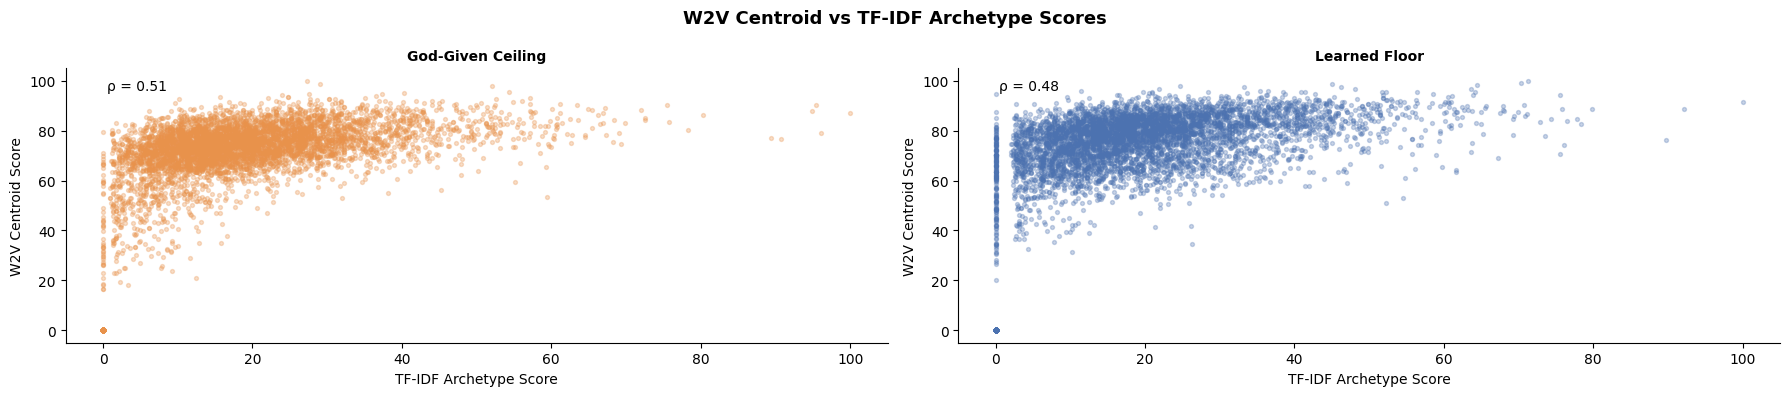

In [51]:
from scipy.stats import spearmanr

_PILLAR_COLORS_ALL = {
    'score_athletic':  '#4C72B0',
    'score_technical': '#55A868',
    'score_character': '#C44E52',
    'score_iq':        '#8172B2',
    'score_god_given': '#E8924B',
    'score_learned':   '#4C72B0',
}
pillar_colors = [_PILLAR_COLORS_ALL.get(c, '#888888') for c in SCORE_COLS]

n_pillars = len(SCORE_COLS)
fig, axes = plt.subplots(1, n_pillars, figsize=(9 * n_pillars, 4))
if n_pillars == 1:
    axes = [axes]   # ensure iterable when only 1 pillar

for ax, col, color in zip(axes, SCORE_COLS, pillar_colors):
    ax.scatter(scores_tfidf[col], scores_w2v[col],
               alpha=0.3, s=8, color=color)
    ax.set_xlabel('TF-IDF Archetype Score')
    ax.set_ylabel('W2V Centroid Score')
    ax.set_title(PILLAR_LABELS[col], fontweight='bold', fontsize=10)
    r, _ = spearmanr(scores_tfidf[col], scores_w2v[col])
    ax.text(0.05, 0.92, f'ρ = {r:.2f}', transform=ax.transAxes, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('W2V Centroid vs TF-IDF Archetype Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Position-Level Sanity Check

QBs should score high on IQ, EDGEs on Athletic + Character, OLs on Technical. If the W2V scores respect these intuitions, the learned lexicons are semantically valid.

In [52]:
result_w2v_full   = result_w2v.copy()
result_tfidf_full = result_tfidf.copy()

pos_w2v   = result_w2v_full.groupby('Pos_Group')[SCORE_COLS].mean().round(1)
pos_tfidf = result_tfidf_full.groupby('Pos_Group')[SCORE_COLS].mean().round(1)

sort_col = SCORE_COLS[0]   # sort by first pillar (dynamic)

print('Mean W2V scores by position group:')
print(pos_w2v.sort_values(sort_col, ascending=False).to_string())
print()
print('Mean TF-IDF scores by position group:')
print(pos_tfidf.sort_values(sort_col, ascending=False).to_string())

Mean W2V scores by position group:
           score_god_given  score_learned
Pos_Group                                
EDGE             78.300003      81.800003
LB               76.000000      84.599998
DB               75.000000      74.800003
DT               74.800003      83.199997
WR               71.800003      61.799999
RB               70.099998      68.400002
TE               69.699997      71.400002
OL               68.199997      79.599998
QB               52.299999      64.400002
SPECIAL          34.900002      43.299999

Mean TF-IDF scores by position group:
           score_god_given  score_learned
Pos_Group                                
EDGE                  22.9           25.4
DB                    21.9           19.1
WR                    21.7           16.4
DT                    19.5           24.2
LB                    18.6           23.6
OL                    18.0           20.3
TE                    16.3           18.6
RB                    15.4           15.6
QB

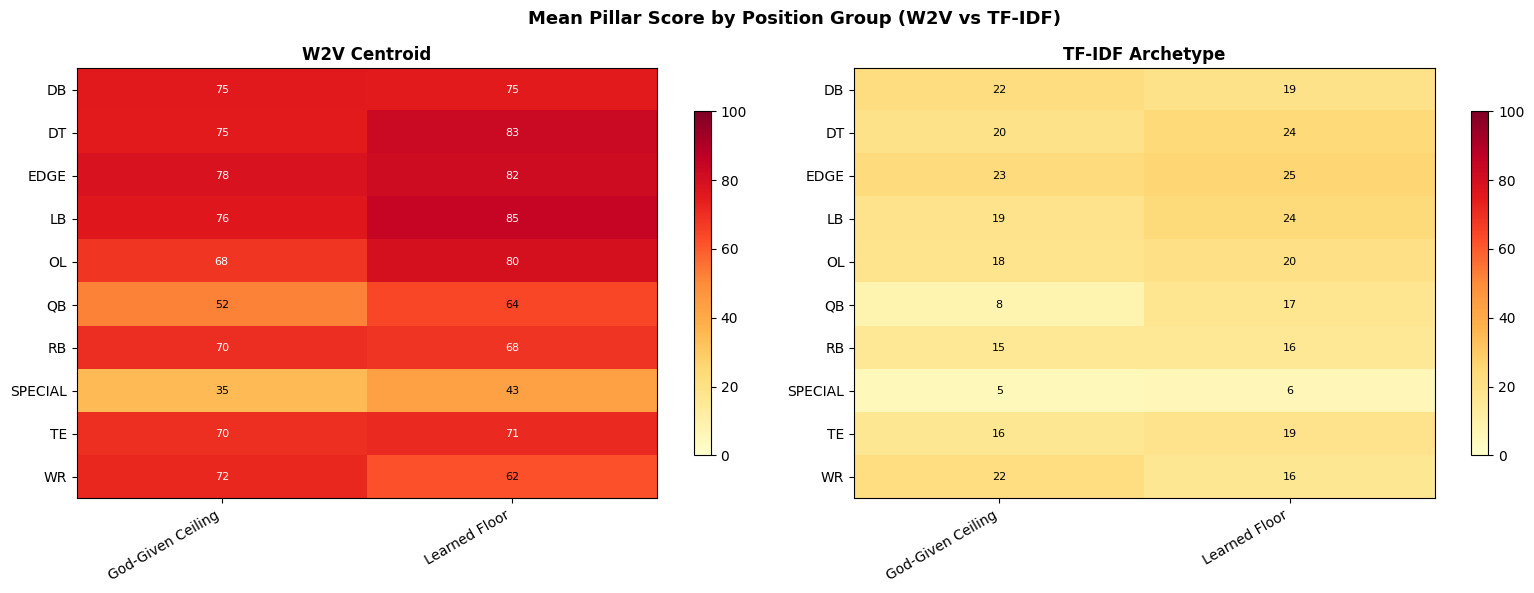

In [53]:
n_pillars = len(SCORE_COLS)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (pos_df, title) in zip(axes, [
    (pos_w2v,   'W2V Centroid'),
    (pos_tfidf, 'TF-IDF Archetype'),
]):
    im = ax.imshow(pos_df.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    ax.set_xticks(range(n_pillars))
    ax.set_xticklabels([PILLAR_LABELS[c] for c in SCORE_COLS], rotation=30, ha='right')
    ax.set_yticks(range(len(pos_df)))
    ax.set_yticklabels(pos_df.index)
    ax.set_title(title, fontweight='bold')
    for i in range(len(pos_df)):
        for j in range(n_pillars):
            ax.text(j, i, f'{pos_df.values[i, j]:.0f}',
                    ha='center', va='center', fontsize=8,
                    color='white' if pos_df.values[i, j] > 65 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)

fig.suptitle('Mean Pillar Score by Position Group (W2V vs TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Learned Dictionary Summary

Export the final learned lexicons — seeds + learned expansions — as interpretable dictionaries you can use to:
- Augment the TF-IDF archetype strings in `nfl_pillar_scoring.ipynb`
- Add missing compound phrases to the curated phrase map
- Build a domain-specific sentiment lexicon per pillar

In [54]:
print('LEARNED PILLAR DICTIONARIES\n')
print('Format: term  |  seed_count (how many seeds it neighbors)  |  avg_sim')

learned_dict_out = {}

for pillar in SCORE_COLS:
    seeds = PILLAR_SEEDS[pillar]
    learned = LEARNED_LEXICONS[pillar]
    # High-confidence: appears near >=2 seeds AND sim >= threshold
    high_conf = learned[learned['seed_count'] >= 2].head(20)
    # Include seeds themselves
    all_terms = [s for s in seeds if s in w2v.wv] + high_conf['term'].tolist()
    learned_dict_out[pillar] = all_terms

    print(f'\n{"═" * 55}')
    print(f'  {PILLAR_LABELS[pillar]}')
    print(f'  Seeds ({len(seeds)}): {seeds}')
    print(f'  Learned high-confidence terms (seed_count >= 2):')
    if len(high_conf) > 0:
        for _, row in high_conf.iterrows():
            print(f'    {row["term"]:30s}  seeds={row["seed_count"]}  avg_sim={row["avg_sim"]}')
    else:
        print('    None at seed_count >= 2 — consider lowering SIM_THRESHOLD or increasing W2V_EPOCHS')

LEARNED PILLAR DICTIONARIES

Format: term  |  seed_count (how many seeds it neighbors)  |  avg_sim

═══════════════════════════════════════════════════════
  God-Given Ceiling
  Seeds (13): ['explosive', 'burst', 'speed', 'quick_twitch', 'get_off', 'twitch', 'twitchy', 'acceleration', 'first_step', 'change_of_direction', 'agility', 'frame', 'size']
  Learned high-confidence terms (seed_count >= 2):
    quickness                       seeds=4  avg_sim=0.584
    short_area                      seeds=4  avg_sim=0.578
    redmond                         seeds=4  avg_sim=0.572
    top_end                         seeds=3  avg_sim=0.599
    juice                           seeds=3  avg_sim=0.579
    play_speed                      seeds=3  avg_sim=0.558
    fluidity                        seeds=3  avg_sim=0.53
    looseness                       seeds=3  avg_sim=0.519
    confirmed                       seeds=3  avg_sim=0.506
    pearce                          seeds=3  avg_sim=0.506
    later

In [55]:
# Identify learned terms that are STITCHED TOKENS (compound phrases)
# These are candidates to add to CURATED_PHRASE_MAP if not already there
print('New compound phrases discovered by W2V that could be added to CURATED_PHRASE_MAP:')
print('(stitched tokens not already in curated list)\n')

existing_tokens = set(CURATED_PHRASE_MAP.values())

for pillar in SCORE_COLS:
    lex = LEARNED_LEXICONS[pillar]
    new_compounds = lex[lex['term'].str.contains('_') & ~lex['term'].isin(existing_tokens)]
    if len(new_compounds) > 0:
        print(f'{PILLAR_LABELS[pillar]}:')
        for _, row in new_compounds.head(10).iterrows():
            phrase = row['term'].replace('_', ' ')
            print(f"  '{phrase}': '{row['term']}',   # seed_count={row['seed_count']}, sim={row['avg_sim']}")
        print()

New compound phrases discovered by W2V that could be added to CURATED_PHRASE_MAP:
(stitched tokens not already in curated list)

God-Given Ceiling:
  'short areas': 'short_areas',   # seed_count=2, sim=0.527
  'two gaps': 'two_gaps',   # seed_count=1, sim=0.524
  'one gapper': 'one_gapper',   # seed_count=1, sim=0.517
  'pass setting': 'pass_setting',   # seed_count=1, sim=0.478

Learned Floor:
  'pass rushes': 'pass_rushes',   # seed_count=1, sim=0.489



## Summary

### What was learned

- **Word2Vec** trained on ~3k scouting reports learns a semantic embedding space where NFL scouting terms cluster naturally
- The pillar centroids are built from seed embeddings + learned expansions — no manual archetype string needed
- High `seed_count` terms are the most reliable additions to each pillar's vocabulary

### Next steps

1. **Augment `nfl_pillar_scoring.ipynb`** — add the high-confidence learned terms to each archetype string
2. **Add new compound phrases** to `CURATED_PHRASE_MAP` — especially IQ and Character terms that W2V discovers as stitched tokens
3. **Hybrid scoring** — average W2V centroid similarity and TF-IDF archetype similarity for a more robust score
4. **Position-stratified centroids** — train separate centroids per `Pos_Group` (a QB's "football IQ" manifests in different vocabulary than a lineman's)